In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path= "C:/Users/wellw/Downloads/SOLTRACK_CLEANED.csv"
df = pd.read_csv(file_path)
# View the data in tabular format
df.head()

,Index,Time Stamp,Time (s),Temperature (°C),Humidity (%),LDR1 Top (V),LDR2 Right (V),LDR3 Down (V),LDR4 Left (V),Tracked Azimuth (deg),Tracked Zenith (deg)
0,1,2025-01-01 00:00:00,0,26.935707,53.942462,0.000000,0.03204,0.084214,0.035055,69.129961,85.878934
1,2,2025-01-01 00:00:15,15,26.683066,54.726498,0.000000,0.00000,0.075650,0.007008,89.737530,86.030850
2,3,2025-01-01 00:00:30,30,26.755107,53.846696,0.047136,0.00000,0.000000,0.054710,86.611051,90.000000
3,4,2025-01-01 00:00:45,45,25.859434,52.276270,0.147144,0.00000,0.048742,0.089915,101.312175,90.000000
4,5,2025-01-01 00:01:00,60,27.015102,52.354471,0.056631,0.00000,0.275075,0.000000,99.080142,87.747829


In [3]:
# Check your data structure
print(df.info())
print(df.head())

# Check time consistency (Edge Impulse loves regular intervals)
df['Time Diff'] = df['Time (s)'].diff()
print(df['Time Diff'].value_counts().head(10))

<class 'pandas.DataFrame'>
RangeIndex: 77724 entries, 0 to 77723
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Index                  77724 non-null  int64  
 1   Time Stamp             77724 non-null  str    
 2   Time (s)               77724 non-null  int64  
 3   Temperature (°C)       77724 non-null  float64
 4   Humidity (%)           77724 non-null  float64
 5   LDR1 Top (V)           77724 non-null  float64
 6   LDR2 Right (V)         77724 non-null  float64
 7   LDR3 Down (V)          77724 non-null  float64
 8   LDR4 Left (V)          77724 non-null  float64
 9   Tracked Azimuth (deg)  77724 non-null  float64
 10  Tracked Zenith (deg)   77724 non-null  float64
dtypes: float64(8), int64(2), str(1)
memory usage: 6.5 MB
None
   Index           Time Stamp  Time (s)  Temperature (°C)  Humidity (%)  \
0      1  2025-01-01 00:00:00         0         26.935707     53.942462   
1      2  202

In [4]:
# First, check your actual column names
print(df.columns.tolist())
# 1. Rolling averages (smooths out noise)
df['LDR1_Avg5'] = df['LDR1 Top (V)'].rolling(window=5).mean()
df['LDR2_Avg5'] = df['LDR2 Right (V)'].rolling(window=5).mean()
df['LDR3_Avg5'] = df['LDR3 Down (V)'].rolling(window=5).mean()
df['LDR4_Avg5'] = df['LDR4 Left (V)'].rolling(window=5).mean()

# 2. LDR differences (which side is brighter)
df['LDR_Top_Bottom'] = df['LDR1 Top (V)'] - df['LDR3 Down (V)']
df['LDR_Right_Left'] = df['LDR2 Right (V)'] - df['LDR4 Left (V)']

# 3. Rate of change (how fast is light changing)
df['LDR1_Rate'] = df['LDR1 Top (V)'].diff()
df['LDR2_Rate'] = df['LDR2 Right (V)'].diff()
df['LDR3_Rate'] = df['LDR3 Down (V)'].diff()
df['LDR4_Rate'] = df['LDR4 Left (V)'].diff()

# 4. Total light level
df['LDR_Total'] = df[['LDR1 Top (V)', 'LDR2 Right (V)', 'LDR3 Down (V)', 'LDR4 Left (V)']].sum(axis=1)

# 5. Light balance (0 = perfectly balanced = panel aligned)
df['LDR_Balance'] = abs(df['LDR_Top_Bottom']) + abs(df['LDR_Right_Left'])

# Check new features
print(df[['LDR1 Top (V)', 'LDR1_Avg5', 'LDR_Top_Bottom', 'LDR1_Rate', 'LDR_Balance']].head())

['Index', 'Time Stamp', 'Time (s)', 'Temperature (°C)', 'Humidity (%)', 'LDR1 Top (V)', 'LDR2 Right (V)', 'LDR3 Down (V)', 'LDR4 Left (V)', 'Tracked Azimuth (deg)', 'Tracked Zenith (deg)', 'Time Diff']
   LDR1 Top (V)  LDR1_Avg5  LDR_Top_Bottom  LDR1_Rate  LDR_Balance
0      0.000000        NaN       -0.084214        NaN     0.087229
1      0.000000        NaN       -0.075650   0.000000     0.082658
2      0.047136        NaN        0.047136   0.047136     0.101846
3      0.147144        NaN        0.098402   0.100008     0.188317
4      0.056631   0.050182       -0.218444  -0.090512     0.218444


In [5]:
# Select columns to keep for Edge Impulse
edge_cols = [
    'LDR1 Top (V)', 'LDR2 Right (V)', 'LDR3 Down (V)', 'LDR4 Left (V)',
    'Temperature (°C)', 'Humidity (%)',
    'LDR_Top_Bottom', 'LDR_Right_Left',
    'LDR1_Rate', 'LDR2_Rate', 'LDR3_Rate', 'LDR4_Rate',
    'LDR_Total', 'LDR_Balance',
    'Tracked Azimuth (deg)', 'Tracked Zenith (deg)'
]

df_edge = df[edge_cols].copy()

# Remove NaN rows (from rolling/diff operations)
df_edge = df_edge.dropna()

# Save for Edge Impulse
df_edge.to_csv('SOLTRACK_EDGE_IMPULSE.csv', index=False)
print(f"Saved {len(df_edge)} rows for Edge Impulse")

Saved 77723 rows for Edge Impulse


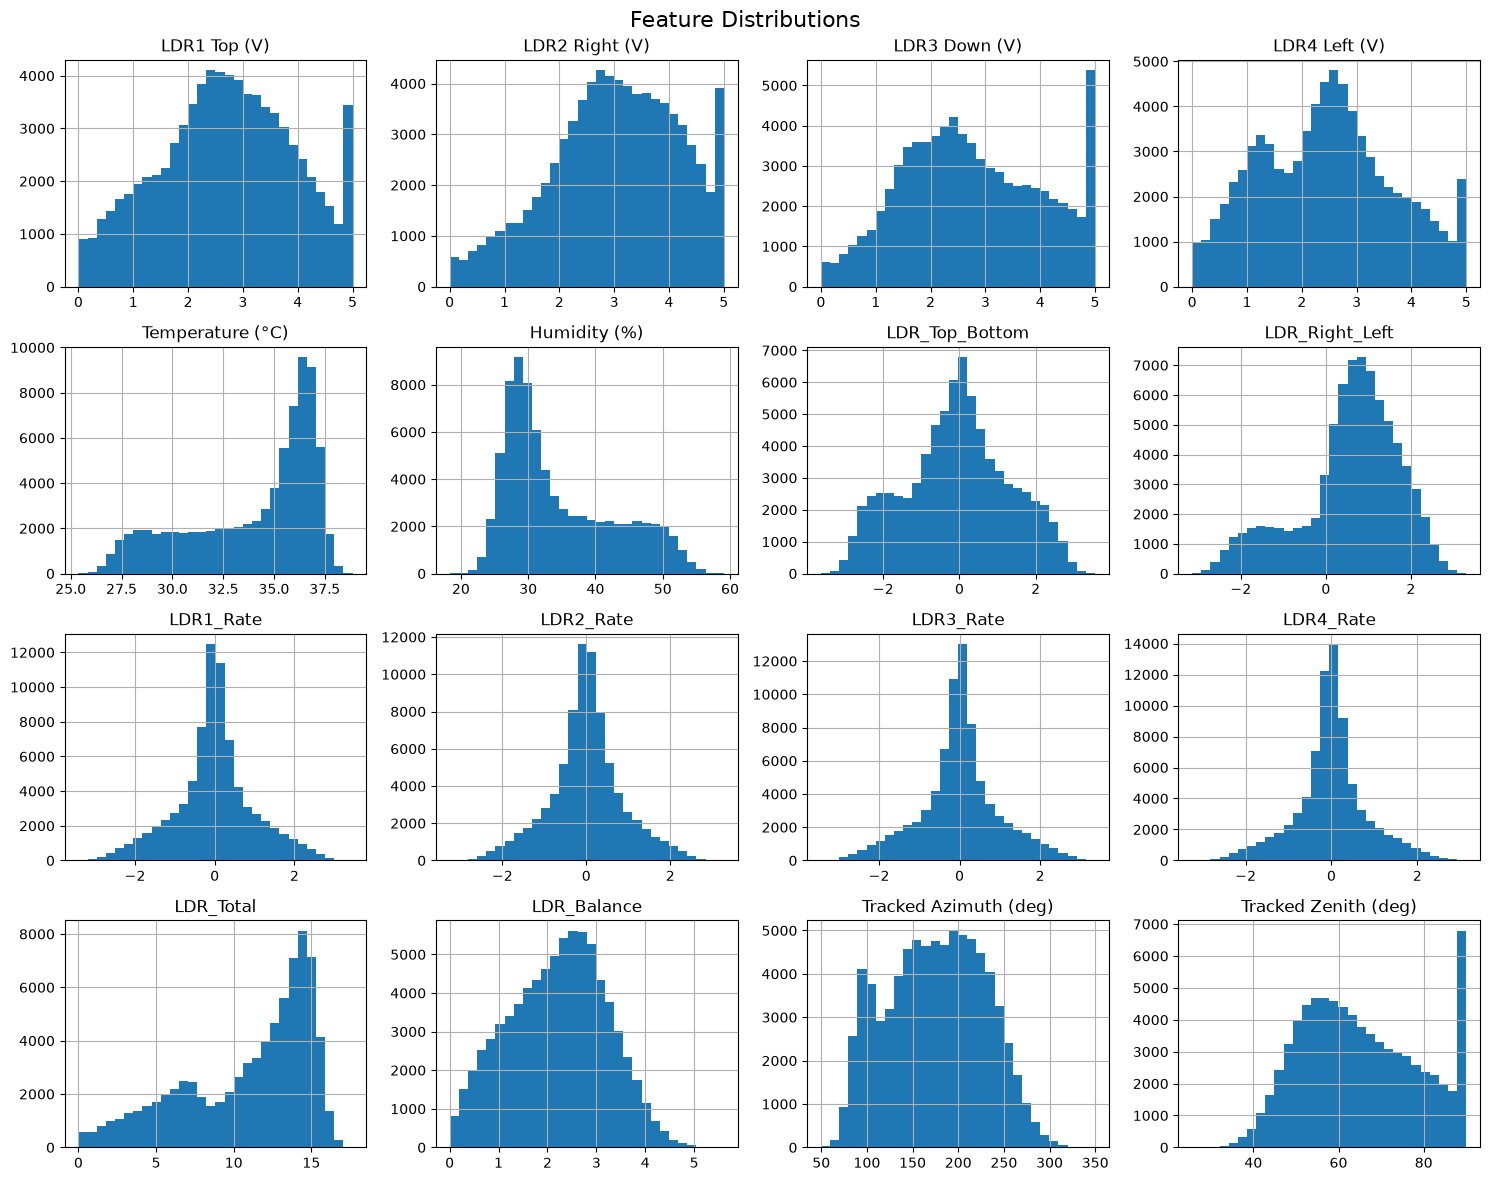

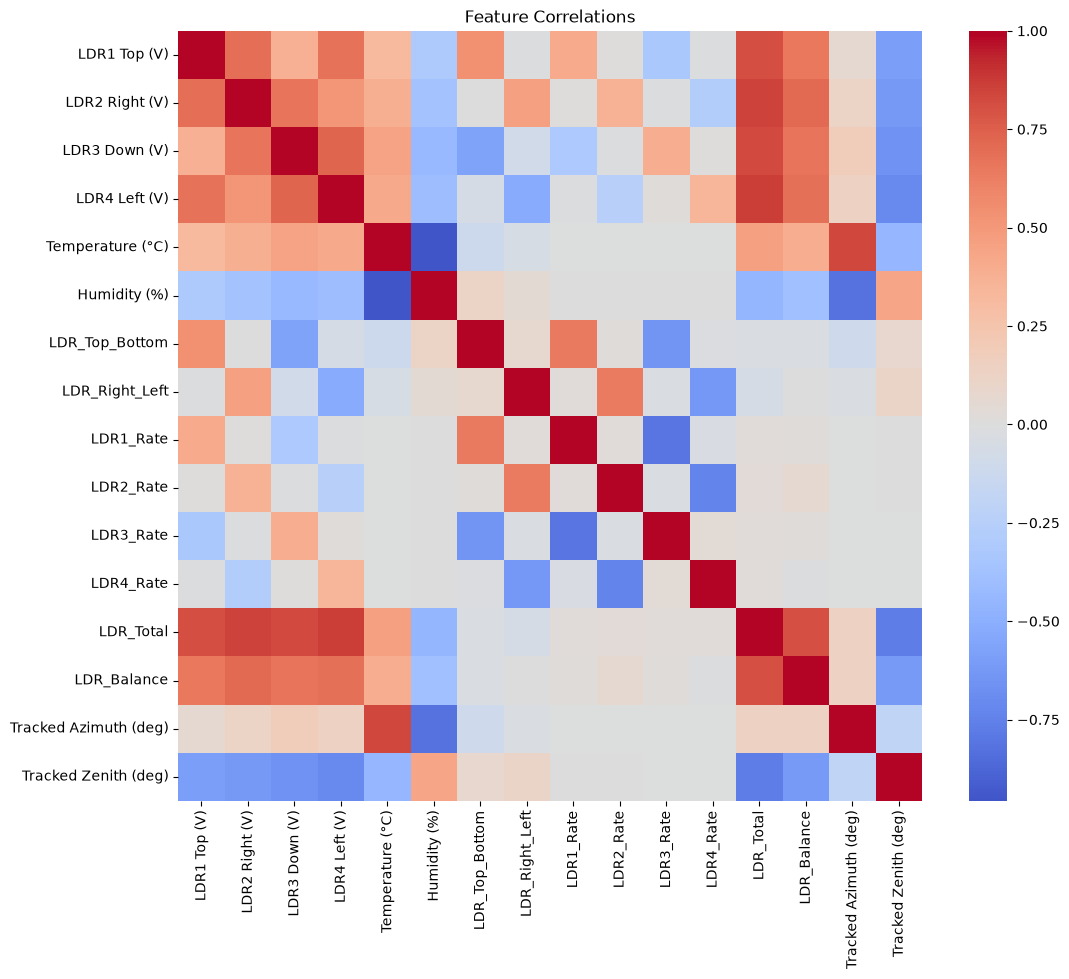

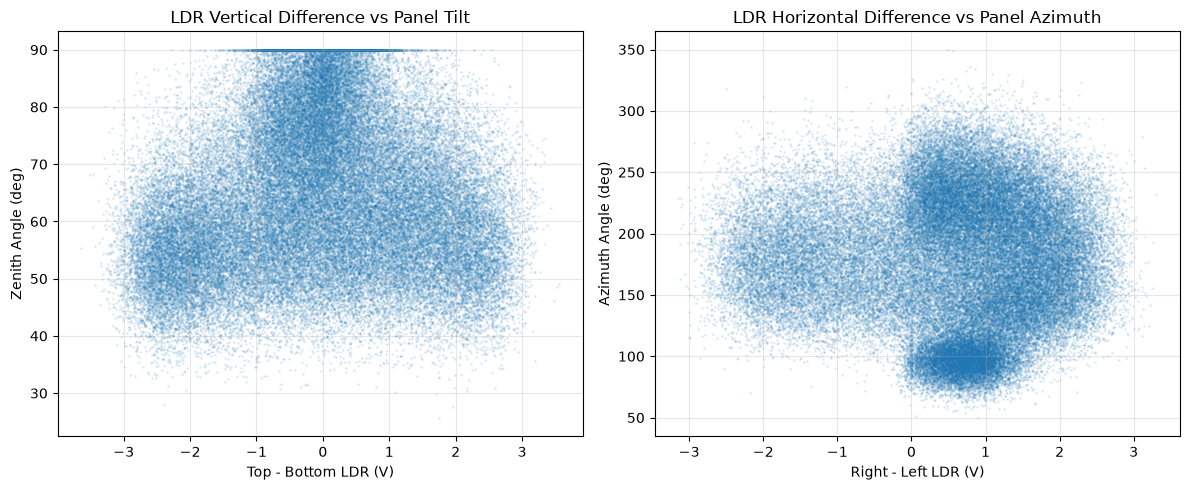

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature distributions
df_edge.hist(figsize=(15, 12), bins=30)
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Correlation matrix (shows which features matter most)
plt.figure(figsize=(12, 10))
corr = df_edge.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

# 3. LDR vs Panel Position
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_edge['LDR_Top_Bottom'], df_edge['Tracked Zenith (deg)'], alpha=0.1, s=1)
plt.xlabel('Top - Bottom LDR (V)')
plt.ylabel('Zenith Angle (deg)')
plt.title('LDR Vertical Difference vs Panel Tilt')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(df_edge['LDR_Right_Left'], df_edge['Tracked Azimuth (deg)'], alpha=0.1, s=1)
plt.xlabel('Right - Left LDR (V)')
plt.ylabel('Azimuth Angle (deg)')
plt.title('LDR Horizontal Difference vs Panel Azimuth')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# 1. Check for any remaining missing values
print(f"Missing values: {df_edge.isnull().sum().sum()}")

# 2. Check for infinite values
print(f"Infinite values: {np.isinf(df_edge.values).sum()}")

# 3. Check value ranges (Edge Impulse likes normalized data)
print("Value ranges:")
for col in df_edge.columns:
    print(f"{col}: {df_edge[col].min():.3f} to {df_edge[col].max():.3f}")

# 4. Sample of the data (first 10 rows)
print("\nFirst 10 rows for Edge Impulse:")
print(df_edge.head(10))

Missing values: 0
Infinite values: 0
Value ranges:
LDR1 Top (V): 0.000 to 5.000
LDR2 Right (V): 0.000 to 5.000
LDR3 Down (V): 0.000 to 5.000
LDR4 Left (V): 0.000 to 5.000
Temperature (°C): 25.380 to 38.867
Humidity (%): 18.333 to 59.071
LDR_Top_Bottom: -3.635 to 3.558
LDR_Right_Left: -3.143 to 3.302
LDR1_Rate: -3.418 to 3.457
LDR2_Rate: -3.252 to 3.275
LDR3_Rate: -3.442 to 3.365
LDR4_Rate: -3.243 to 3.141
LDR_Total: 0.000 to 17.653
LDR_Balance: 0.000 to 5.607
Tracked Azimuth (deg): 49.632 to 349.804
Tracked Zenith (deg): 25.642 to 90.000

First 10 rows for Edge Impulse:
    LDR1 Top (V)  LDR2 Right (V)  LDR3 Down (V)  LDR4 Left (V)  \
1       0.000000        0.000000       0.075650       0.007008   
2       0.047136        0.000000       0.000000       0.054710   
3       0.147144        0.000000       0.048742       0.089915   
4       0.056631        0.000000       0.275075       0.000000   
5       0.000000        0.090617       0.000000       0.000000   
6       0.000000        0.0

In [9]:
# STEP 6: Add Labels (No Power Data - Using LDR Balance Instead)

# 1. Calculate LDR balance
df['LDR_Top_Bottom'] = df['LDR1 Top (V)'] - df['LDR3 Down (V)']
df['LDR_Right_Left'] = df['LDR2 Right (V)'] - df['LDR4 Left (V)']
df['LDR_Balance'] = abs(df['LDR_Top_Bottom']) + abs(df['LDR_Right_Left'])

# 2. Calculate total light
df['LDR_Total'] = df[['LDR1 Top (V)', 'LDR2 Right (V)', 'LDR3 Down (V)', 'LDR4 Left (V)']].sum(axis=1)

# 3. Create Alignment_Quality label (Good if balance < 0.3V)
df['Alignment_Quality'] = df['LDR_Balance'].apply(
    lambda x: 'Good' if x < 0.3 else 'Poor'
)

# 4. Create Movement_Direction label
conditions = [
    (df['LDR_Top_Bottom'] > 0.05),  # Top brighter → move up
    (df['LDR_Top_Bottom'] < -0.05), # Bottom brighter → move down
    (df['LDR_Right_Left'] > 0.05),  # Right brighter → move right
    (df['LDR_Right_Left'] < -0.05), # Left brighter → move left
    (abs(df['LDR_Top_Bottom']) <= 0.05) & (abs(df['LDR_Right_Left']) <= 0.05)  # Balanced → stay
]
choices = ['Move_Up', 'Move_Down', 'Move_Right', 'Move_Left', 'Stay']
df['Movement_Direction'] = np.select(conditions, choices, default='Stay')

# 5. Create Light_Condition label
df['Light_Condition'] = pd.cut(
    df['LDR_Total'],
    bins=[0, 0.5, 2.0, 20],
    labels=['Dark', 'Moderate', 'Bright']
)

# 6. Create Tracking_State label (combined)
def determine_tracking_state(row):
    total_light = row['LDR_Total']
    balance = row['LDR_Balance']
    
    if total_light < 0.5:
        return 'Night_Stowed'
    elif total_light < 1.5:
        return 'Cloudy_Tracking'
    else:
        if balance < 0.3:
            return 'Sunny_Aligned'
        else:
            return 'Sunny_Tracking'

df['Tracking_State'] = df.apply(determine_tracking_state, axis=1)

# 7. Check label distributions
print("\n=== Label Distributions ===")
print("\nAlignment_Quality:")
print(df['Alignment_Quality'].value_counts())
print("\nMovement_Direction:")
print(df['Movement_Direction'].value_counts())
print("\nLight_Condition:")
print(df['Light_Condition'].value_counts())
print("\nTracking_State:")
print(df['Tracking_State'].value_counts())

# 8. Select columns for Edge Impulse with labels
edge_cols = [
    'LDR1 Top (V)', 'LDR2 Right (V)', 'LDR3 Down (V)', 'LDR4 Left (V)',
    'Temperature (°C)', 'Humidity (%)',
    'LDR_Top_Bottom', 'LDR_Right_Left', 'LDR_Balance',
    'LDR_Total',
    'Alignment_Quality',      # LABEL 1
    'Movement_Direction',     # LABEL 2
    'Light_Condition',        # LABEL 3
    'Tracking_State',         # LABEL 4
    'Tracked Azimuth (deg)', 'Tracked Zenith (deg)'
]

df_edge_labeled = df[edge_cols].copy()
df_edge_labeled = df_edge_labeled.dropna()

# 9. Save labeled data
df_edge_labeled.to_csv('SOLTRACK_EDGE_IMPULSE_LABELED.csv', index=False)
print(f"\n✅ Saved {len(df_edge_labeled)} rows with labels to SOLTRACK_EDGE_IMPULSE_LABELED.csv")

# 10. Preview the labeled data
print("\n=== Preview Labeled Data ===")
print(df_edge_labeled[['LDR_Balance', 'Alignment_Quality', 'Movement_Direction', 'Light_Condition', 'Tracking_State']].head(10))


=== Label Distributions ===

Alignment_Quality:
Alignment_Quality
Poor    76086
Good     1638
Name: count, dtype: int64

Movement_Direction:
Movement_Direction
Move_Down     38163
Move_Up       36590
Move_Right     2455
Move_Left       351
Stay            165
Name: count, dtype: int64

Light_Condition:
Light_Condition
Bright      75407
Moderate     1797
Dark          494
Name: count, dtype: int64

Tracking_State:
Tracking_State
Sunny_Tracking     75456
Cloudy_Tracking     1048
Sunny_Aligned        700
Night_Stowed         520
Name: count, dtype: int64

✅ Saved 77698 rows with labels to SOLTRACK_EDGE_IMPULSE_LABELED.csv

=== Preview Labeled Data ===
   LDR_Balance Alignment_Quality Movement_Direction Light_Condition  \
0     0.087229              Good          Move_Down            Dark   
1     0.082658              Good          Move_Down            Dark   
2     0.101846              Good          Move_Left            Dark   
3     0.188317              Good            Move_Up       

In [10]:
# Split into train and test (80/20)
train_size = int(len(df_edge) * 0.8)
train_df = df_edge[:train_size]
test_df = df_edge[train_size:]

# Save separately
train_df.to_csv('SOLTRACK_TRAIN.csv', index=False)
test_df.to_csv('SOLTRACK_TEST.csv', index=False)
print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

Train: 62178 rows, Test: 15545 rows


In [1]:
import pandas as pd
train_data = pd.read_csv("C:/Users/wellw/Downloads/Solar_Tracker/SOLTRACK_TRAIN.csv")
test_data = pd.read_csv("C:/Users/wellw/Downloads/Solar_Tracker/SOLTRACK_TEST.csv")

In [2]:
print(train_data.shape)
print(test_data.shape)
train_data.head()

(62178, 16)
(15545, 16)


,LDR1 Top (V),LDR2 Right (V),LDR3 Down (V),LDR4 Left (V),Temperature (°C),Humidity (%),LDR_Top_Bottom,LDR_Right_Left,LDR1_Rate,LDR2_Rate,LDR3_Rate,LDR4_Rate,LDR_Total,LDR_Balance,Tracked Azimuth (deg),Tracked Zenith (deg)
0,0.000000,0.000000,0.075650,0.007008,26.683066,54.726498,-0.075650,-0.007008,0.000000,-0.032040,-0.008564,-0.028047,0.082658,0.082658,89.737530,86.030850
1,0.047136,0.000000,0.000000,0.054710,26.755107,53.846696,0.047136,-0.054710,0.047136,0.000000,-0.075650,0.047703,0.101846,0.101846,86.611051,90.000000
2,0.147144,0.000000,0.048742,0.089915,25.859434,52.276270,0.098402,-0.089915,0.100008,0.000000,0.048742,0.035205,0.285801,0.188317,101.312175,90.000000
3,0.056631,0.000000,0.275075,0.000000,27.015102,52.354471,-0.218444,0.000000,-0.090512,0.000000,0.226334,-0.089915,0.331707,0.218444,99.080142,87.747829
4,0.000000,0.090617,0.000000,0.000000,25.918808,53.476717,0.000000,0.090617,-0.056631,0.090617,-0.275075,0.000000,0.090617,0.090617,90.260663,84.755780


In [3]:
# Load Pre-split Datasets & Define Features
import numpy as np
import pandas as pd

# 1. Load the pre-engineered training and testing datasets
train_df = pd.read_csv("C:/Users/wellw/Downloads/Solar_Tracker/SOLTRACK_TRAIN.csv")
test_df = pd.read_csv("C:/Users/wellw/Downloads/Solar_Tracker/SOLTRACK_TEST.csv")

# 2. Separate Features (X) and Targets (y)
target_cols = ["Tracked Azimuth (deg)", "Tracked Zenith (deg)"]

X_train = train_df.drop(columns=target_cols)
y_train = train_df[target_cols]

X_test = test_df.drop(columns=target_cols)
y_test = test_df[target_cols]

print(f"Features: {list(X_train.columns)}")
print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Features: ['LDR1 Top (V)', 'LDR2 Right (V)', 'LDR3 Down (V)', 'LDR4 Left (V)', 'Temperature (°C)', 'Humidity (%)', 'LDR_Top_Bottom', 'LDR_Right_Left', 'LDR1_Rate', 'LDR2_Rate', 'LDR3_Rate', 'LDR4_Rate', 'LDR_Total', 'LDR_Balance']
Training samples: 62178 | Testing samples: 15545


In [ ]:
%pip install scikit-learn

In [ ]:
import sys
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize Random Forest (n_jobs=1 prevents Jupyter freeze)
print("1/3 Initializing model...")
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=1,  # Set to 1 to prevent Jupyter threading locks
    verbose=1,  # Displays actual training progress bars
)

# 2. Train Model
print("2/3 Fitting dataset (this takes ~10-15 seconds)...")
sys.stdout.flush()
model.fit(X_train, y_train)

# 3. Predict & Evaluate
print("\n3/3 Predicting test set and computing metrics...")
y_pred = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=target_cols, index=y_test.index)

print("\n" + "=" * 35)
print("      MODEL RESULTS")
print("=" * 35)
for target in target_cols:
    mae = mean_absolute_error(y_test[target], y_pred_df[target])
    rmse = np.sqrt(mean_squared_error(y_test[target], y_pred_df[target]))
    r2 = r2_score(y_test[target], y_pred_df[target])

    print(f"\n[{target}]")
    print(f"  • MAE  (Mean Absolute Error) : {mae:.4f}°")
    print(f"  • RMSE (Root Mean Sq Error)  : {rmse:.4f}°")
    print(f"  • R²   (Accuracy Score)      : {r2:.4f}")

In [1]:
%pip install emlearn



   ---------------------------------------- 0/2 [pybind11]
   -------------------- ------------------- 1/2 [emlearn]
   -------------------- ------------------- 1/2 [emlearn]
   ---------------------------------------- 2/2 [emlearn]

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import emlearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- STEP 1: Load data ---
train_df = pd.read_csv("C:/Users/wellw/Downloads/Solar_Tracker/SOLTRACK_TRAIN.csv")
test_df  = pd.read_csv("C:/Users/wellw/Downloads/Solar_Tracker/SOLTRACK_TEST.csv")

target_cols = ["Tracked Azimuth (deg)", "Tracked Zenith (deg)"]
X_train = train_df.drop(columns=target_cols)
y_train = train_df[target_cols]
X_test  = test_df.drop(columns=target_cols)
y_test  = test_df[target_cols]

# --- SPEED BOOST: subsample the training set to 15,000 rows ---
SUBSET = 15000
if len(X_train) > SUBSET:
    idx = np.random.RandomState(42).choice(len(X_train), SUBSET, replace=False)
    X_train = X_train.iloc[idx].reset_index(drop=True)
    y_train = y_train.iloc[idx].reset_index(drop=True)

print(f"Training on {len(X_train)} rows, testing on {len(X_test)} rows")

# --- STEP 2: Smaller, faster models ---
print("Training Azimuth model...")
model_azimuth = RandomForestRegressor(
    n_estimators=25,      # was 50
    max_depth=10,         # was 12
    min_samples_leaf=5,   # speeds up + reduces tree size for MCU
    random_state=42,
    n_jobs=-1,            # use ALL cores — much faster now
)
model_azimuth.fit(X_train, y_train["Tracked Azimuth (deg)"])
print("  done.")

print("Training Zenith model...")
model_zenith = RandomForestRegressor(
    n_estimators=25,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
model_zenith.fit(X_train, y_train["Tracked Zenith (deg)"])
print("  done.")

# --- STEP 3: Evaluate ---
print("\n=== MODEL RESULTS ===")
pred_az = model_azimuth.predict(X_test)
pred_ze = model_zenith.predict(X_test)

for name, y_true, y_pred in [
    ("Azimuth", y_test["Tracked Azimuth (deg)"], pred_az),
    ("Zenith",  y_test["Tracked Zenith (deg)"],  pred_ze),
]:
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"[{name}] MAE: {mae:.4f}°  R²: {r2:.4f}")

# --- STEP 4: Convert to C headers ---
print("\nConverting to C headers...")
emlearn.convert(model_azimuth, method='inline').save(
    file='model_azimuth.h', name='sol_track_azimuth')
emlearn.convert(model_zenith, method='inline').save(
    file='model_zenith.h', name='sol_track_zenith')

print("✅ Generated model_azimuth.h and model_zenith.h")

Training on 15000 rows, testing on 15545 rows
Training Azimuth model...
  done.
Training Zenith model...
  done.

=== MODEL RESULTS ===
[Azimuth] MAE: 18.5596°  R²: 0.8034
[Zenith] MAE: 6.4530°  R²: 0.6954

Converting to C headers...
✅ Generated model_azimuth.h and model_zenith.h


In [6]:
import os
cwd = os.getcwd()
print(f"Notebook working directory: {cwd}")
for f in ["model_azimuth.h", "model_zenith.h"]:
    path = os.path.join(cwd, f)
    if os.path.exists(path):
        print(f"✅ {path}  ({os.path.getsize(path)/1024:.1f} KB)")
    else:
        print(f"❌ NOT FOUND at {path}")

Notebook working directory: C:\Users\wellw
✅ C:\Users\wellw\model_azimuth.h  (2074.7 KB)
✅ C:\Users\wellw\model_zenith.h  (2239.1 KB)


In [7]:
for f in ["model_azimuth.h", "model_zenith.h"]:
    path = os.path.join(os.getcwd(), f)
    print(f"\n=== {f} ===")
    with open(path) as fh:
        for line in fh:
            stripped = line.strip()
            # emlearn generates functions ending in _predict
            if "_predict" in stripped and "(" in stripped and ";" in stripped:
                print(stripped)


=== model_azimuth.h ===

=== model_zenith.h ===


In [9]:
import os
import shutil

cwd = os.getcwd()
print(f"Notebook working directory: {cwd}")

# Where we want them
dest = r"C:/Users/wellw/Downloads"

# Search for the files — first in cwd, then scan Downloads/Solar_Tracker
candidates = [
    os.path.join(cwd, "model_azimuth.h"),
    os.path.join(cwd, "model_zenith.h"),
    r"C:/Users/wellw/Downloads/Solar_Tracker/model_azimuth.h",
    r"C:/Users/wellw/Downloads/Solar_Tracker/model_zenith.h",
]

found = []
for path in candidates:
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✅ FOUND: {path}  ({size_kb:.1f} KB)")
        found.append(path)
    else:
        print(f"❌ not at: {path}")

Notebook working directory: C:\Users\wellw
✅ FOUND: C:\Users\wellw\model_azimuth.h  (2074.7 KB)
✅ FOUND: C:\Users\wellw\model_zenith.h  (2239.1 KB)
❌ not at: C:/Users/wellw/Downloads/Solar_Tracker/model_azimuth.h
❌ not at: C:/Users/wellw/Downloads/Solar_Tracker/model_zenith.h


In [10]:
for path in found:
    filename = os.path.basename(path)
    target = os.path.join(dest, filename)
    shutil.copy2(path, target)   # copy, not move — keeps original as backup
    print(f"Copied → {target}  ({os.path.getsize(target)/1024:.1f} KB)")

Copied → C:/Users/wellw/Downloads\model_azimuth.h  (2074.7 KB)
Copied → C:/Users/wellw/Downloads\model_zenith.h  (2239.1 KB)


In [13]:
import os
os.environ["JOBLIB_START_METHOD"] = "spawn"   # Windows fix — must be before sklearn

import time
import numpy as np
import pandas as pd
import emlearn
from sklearn.ensemble import RandomForestRegressor

BASE = r"C:/Users/wellw/Downloads/Solar_Tracker"

# ---------- Load ----------
t0 = time.time()
train_df = pd.read_csv(f"{BASE}/SOLTRACK_TRAIN.csv")
print(f"Loaded {len(train_df)} rows in {time.time()-t0:.1f}s")

target_cols = ["Tracked Azimuth (deg)", "Tracked Zenith (deg)"]
X    = train_df.drop(columns=target_cols).values.astype(np.float32)
y_az = train_df["Tracked Azimuth (deg)"].values.astype(np.float32)
y_ze = train_df["Tracked Zenith (deg)"].values.astype(np.float32)

# ---------- Aggressive subsample: 6000 rows is plenty ----------
SUBSET = 6000
if len(X) > SUBSET:
    idx = np.random.RandomState(42).choice(len(X), SUBSET, replace=False)
    X, y_az, y_ze = X[idx], y_az[idx], y_ze[idx]
print(f"Subsampled to {len(X)} rows")

# ---------- Tiny, fast models ----------
def train(y, label):
    print(f"Training {label} ...")
    t = time.time()
    m = RandomForestRegressor(
        n_estimators=15,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    )
    m.fit(X, y)
    print(f"  trained in {time.time()-t:.1f}s")
    return m

model_az = train(y_az, "Azimuth")
model_ze = train(y_ze, "Zenith")

# ---------- Convert with dtype='float' — the actual fix ----------
print("Converting to C headers ...")
t = time.time()
emlearn.convert(model_az, method='inline', dtype='float').save(
    file=f"{BASE}/model_azimuth.h", name='sol_track_azimuth')
emlearn.convert(model_ze, method='inline', dtype='float').save(
    file=f"{BASE}/model_zenith.h", name='sol_track_zenith')
print(f"  conversion done in {time.time()-t:.1f}s")

# ---------- Verify ----------
for f in ["model_azimuth.h", "model_zenith.h"]:
    p = f"{BASE}/{f}"
    print(f"{f}: {os.path.getsize(p)/1024:.1f} KB")
    with open(p) as fh:
        for line in fh:
            if "_predict" in line and ";" in line and "(" in line:
                print("   →", line.strip())
                break

print("\n✅ Done. Copy both .h files into Documents/Arduino/Final_project/")

Loaded 62178 rows in 0.7s
Subsampled to 6000 rows
Training Azimuth ...
  trained in 0.3s
Training Zenith ...
  trained in 0.3s
Converting to C headers ...
  conversion done in 17.5s
model_azimuth.h: 390.2 KB
model_zenith.h: 362.3 KB

✅ Done. Copy both .h files into Documents/Arduino/Final_project/


In [14]:
import os, glob

# Check the two locations you care about
locations = [
    r"C:/Users/wellw/Downloads",
    r"C:/Users/wellw/Downloads/Solar_Tracker",
    r"C:/Users/wellw/Documents/Arduino/Final_project",
]

print("=== Checking specific locations ===")
for loc in locations:
    print(f"\n📁 {loc}")
    for f in ["model_azimuth.h", "model_zenith.h"]:
        p = os.path.join(loc, f)
        if os.path.exists(p):
            print(f"   ✅ {f}  ({os.path.getsize(p)/1024:.1f} KB)")
        else:
            print(f"   ❌ {f} NOT here")

# Also search everywhere under your user folder (may take ~20s)
print("\n=== Full search under C:/Users/wellw ===")
found = []
for f in ["model_azimuth.h", "model_zenith.h"]:
    for match in glob.glob(rf"C:/Users/wellw/**/{f}", recursive=True):
        size_kb = os.path.getsize(match) / 1024
        print(f"   {match}  ({size_kb:.1f} KB)")
        found.append(match)

if not found:
    print("   ⚠️ No .h files found anywhere under C:/Users/wellw")

=== Checking specific locations ===

📁 C:/Users/wellw/Downloads
   ✅ model_azimuth.h  (2074.7 KB)
   ✅ model_zenith.h  (2239.1 KB)

📁 C:/Users/wellw/Downloads/Solar_Tracker
   ✅ model_azimuth.h  (390.2 KB)
   ✅ model_zenith.h  (362.3 KB)

📁 C:/Users/wellw/Documents/Arduino/Final_project
   ✅ model_azimuth.h  (2074.7 KB)
   ✅ model_zenith.h  (2239.1 KB)

=== Full search under C:/Users/wellw ===
   C:/Users/wellw\model_azimuth.h  (2074.7 KB)
   C:/Users/wellw\AppData\Local\arduino\sketches\ED54C71D9E0C3D60B3D23F24854BBC03\sketch\model_azimuth.h  (2074.8 KB)
   C:/Users/wellw\AppData\Local\Temp\arduino-language-server1327543705\build\sketch\model_azimuth.h  (2074.8 KB)
   C:/Users/wellw\AppData\Local\Temp\arduino-language-server1327543705\fullbuild\sketch\model_azimuth.h  (2074.8 KB)
   C:/Users/wellw\AppData\Local\Temp\arduino-language-server4214677692\build\sketch\model_azimuth.h  (2074.8 KB)
   C:/Users/wellw\AppData\Local\Temp\arduino-language-server4214677692\fullbuild\sketch\model_a